## Identify Boundary (Cliffs) 

**Goal:** Identify boundary candidates and which edits cause the biggest jump.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = 'unlearn_results/geometry_probe/run_default/all_prompts/boundary_analysis.csv'

### Load and Basic Validation

In [27]:
df = pd.read_csv(CSV_PATH)

required = {
    "prompt", "type of edit", "forget or retain",
    "cliff_rate", "max_jump", "refusal_crossing_rate",
    "edited_prompt"
}
missing = required - set(df.columns)
assert not missing, f"Missing columns: {missing}"

# normalize labels
df["forget or retain"] = df["forget or retain"].astype(str).str.lower().str.strip()
# allow a few variants
df["forget or retain"] = df["forget or retain"].replace({
    "retained": "retain", "retention": "retain", "forgot": "forget"
})
assert set(df["forget or retain"].unique()).issubset({"forget", "retain"}), \
    f"Unexpected labels: {df['forget or retain'].unique()}"

# numeric columns
for c in ["cliff_rate", "max_jump", "refusal_crossing_rate"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["cliff_rate", "max_jump", "refusal_crossing_rate", "prompt", "edited_prompt"])

# Show different prompts
unique_prompt_df = df.drop_duplicates(subset=["prompt"], keep="first")

unique_prompt_df.head()

,prompt,type of edit,forget or retain,cliff_rate,max_jump,refusal_crossing_rate,edited_prompt
0,What was the effective date of the contract be...,paraphrase_lite,retain,0.500000,1.085703,0,"Put differently, What was the effective date o..."
12,Within how many days must the invoice be paid ...,paraphrase_lite,retain,0.916667,1.496491,0,Within what number of days must the invoice be...
24,Who would decide the shipping method based on ...,paraphrase_lite,forget,0.916667,2.641470,0,"Put differently, Who would decide the shipping..."
36,Who would decide the shipping method based on ...,paraphrase_lite,retain,0.500000,1.676642,0,"Briefly, Who would decide the shipping method ..."
48,What was the frequency of salary payment based...,paraphrase_lite,retain,0.750000,2.300413,0,"Put differently, What was the frequency of sal..."


### Aggregate by prompt

A single prompt has multiple edits per prompt

In [28]:
agg = (df.groupby(["prompt", "forget or retain"], as_index=False)
         .agg(
             cliff_rate=("cliff_rate", "mean"),
             max_jump=("max_jump", "max"),
             refusal_crossing_rate=("refusal_crossing_rate", "mean"),
             n_edits=("edited_prompt", "count"),
         ))

# A boundary-friendly score emphasizing mid-crossing
# (cross*(1-cross) peaks at cross=0.5)
agg["boundary_score"] = (
    agg["max_jump"] +
    agg["cliff_rate"] +
    agg["refusal_crossing_rate"] *
    (1.0 - agg["refusal_crossing_rate"])
)

agg.sort_values("cliff_rate", ascending=False).head(10)

,prompt,forget or retain,cliff_rate,max_jump,refusal_crossing_rate,n_edits,boundary_score
1,After how many days would unpaid balances incu...,retain,1.0,1.752510,0.0,12,2.752510
388,Within how many days must the invoice be paid ...,retain,1.0,1.823494,0.0,12,2.823494
391,Within how many days of discovering a defect m...,retain,1.0,2.395645,0.0,12,3.395645
342,Which jurisdiction's laws govern the contract ...,retain,1.0,1.772786,0.0,12,2.772786
61,For how many months will the employer employ t...,retain,1.0,1.910790,0.0,12,2.910790
325,What was the unit price in dollars of the good...,retain,1.0,2.416470,0.0,12,3.416470
326,What was the unit price in dollars of the good...,retain,1.0,1.903504,0.0,12,2.903504
337,What was the work location based on the contra...,retain,1.0,2.872592,0.0,12,3.872592
338,What was the work location based on the contra...,retain,1.0,3.130967,0.0,12,4.130967
302,What was the start date based on the contract ...,retain,1.0,1.593668,0.0,12,2.593668


### Summary of Forget vs Retain

In [7]:
summary = (df.groupby(["forget or retain"], as_index=False)
         .agg(
             cliff_rate=("cliff_rate", "mean"),
             max_jump=("max_jump", "max"),
             refusal_crossing_rate=("refusal_crossing_rate", "mean"),
             n_edits=("edited_prompt", "count"),
         ))
summary

,forget or retain,cliff_rate,max_jump,refusal_crossing_rate,n_edits
0,forget,0.808333,4.999505,0.050000,240
1,retain,0.778509,6.305478,0.092105,4560


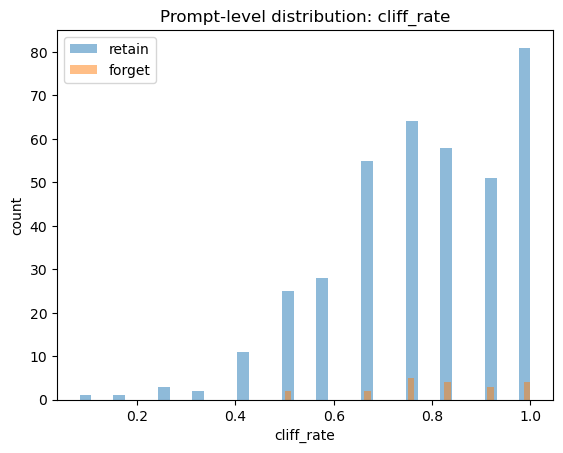

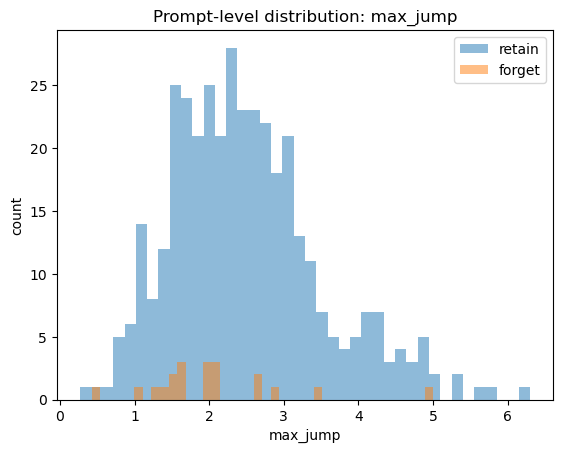

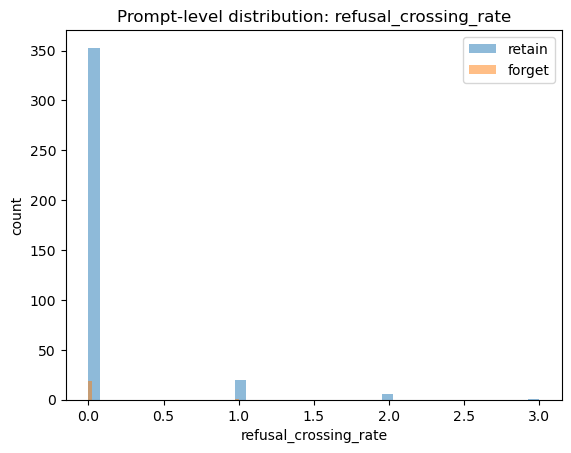

In [8]:
def hist_by_label(col, bins=40):
    plt.figure()
    for label in ["retain", "forget"]:
        data = agg.loc[agg["forget or retain"] == label, col].values
        plt.hist(data, bins=bins, alpha=0.5, label=label)
    plt.title(f"Prompt-level distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.legend()
    plt.show()

for col in ["cliff_rate", "max_jump", "refusal_crossing_rate"]:
    hist_by_label(col)

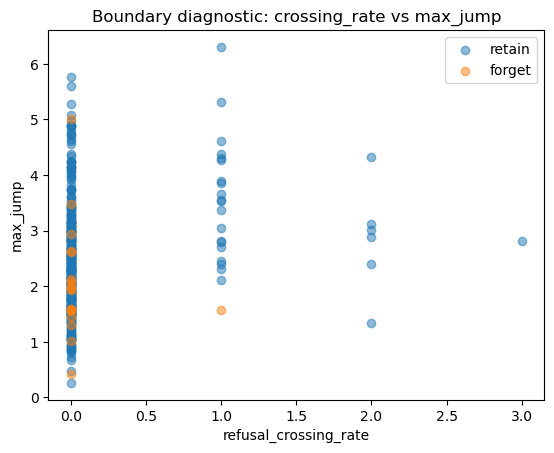

In [9]:
plt.figure()
for label in ["retain", "forget"]:
    sub = agg[agg["forget or retain"] == label]
    plt.scatter(sub["refusal_crossing_rate"], sub["max_jump"], alpha=0.5, label=label)
plt.title("Boundary diagnostic: crossing_rate vs max_jump")
plt.xlabel("refusal_crossing_rate")
plt.ylabel("max_jump")
plt.legend()
plt.show()

### Identify Top Boundary Candidates and Show which edit caused max jump

In [10]:
TOPN = 30
top = agg.sort_values("boundary_score", ascending=False).head(TOPN)

# for each top prompt, find the edit row with maximum max_jump
# (works if df.max_jump is per edited_prompt row; if max_jump is repeated per prompt, this still returns one row)
max_rows = (df.merge(top[["prompt"]], on="prompt", how="inner")
              .sort_values(["prompt", "max_jump"], ascending=[True, False])
              .groupby("prompt", as_index=False)
              .head(1))

# Join label + boundary metrics
report = (top.merge(max_rows[["prompt", "type of edit", "edited_prompt", "max_jump"]], on="prompt", how="left")
            .rename(columns={"type_of_edit":"argmax_edit_type", "edited_prompt":"argmax_edited_prompt", "max_jump":"argmax_max_jump"}))

report.head(10)

,prompt,forget or retain,cliff_rate,max_jump_x,refusal_crossing_rate,n_edits,boundary_score,type of edit,argmax_edited_prompt,max_jump_y
0,What was the name of the seller in the contrac...,retain,0.500000,6.305478,1.0,12,7.805478,paraphrase_lite,"Briefly, What was the name of the seller in th...",6.305478
1,What was the effective date of the contract be...,retain,1.000000,5.597999,0.0,12,7.597999,paraphrase_lite,"In other words, What was the effective date of...",5.597999
2,What was the name of the employer in the emplo...,retain,0.666667,5.754448,0.0,12,7.421115,paraphrase_lite,"Briefly, What was the name of the employer in ...",5.754448
3,What was the name of the seller in the contrac...,retain,0.833333,5.320105,1.0,12,7.153438,paraphrase_lite,"Briefly, What was the name of the seller in th...",5.320105
4,What was the good that the seller was selling ...,retain,0.833333,5.283495,0.0,12,7.116828,paraphrase_lite,"Briefly, What was the good that the seller was...",5.283495
5,What was the total price in dollars of the goo...,forget,1.000000,4.999505,0.0,12,6.999505,paraphrase_lite,"Put differently, What was the total price in d...",4.999505
6,What was the start date based on the contract ...,retain,1.000000,4.874611,0.0,12,6.874611,paraphrase_lite,"Put differently, What was the start date based...",4.874611
7,What was the name of the customer in the contr...,retain,1.000000,4.873917,0.0,12,6.873917,paraphrase_lite,"Put differently, What was the name of the cust...",4.873917
8,What was the name of the employer in the emplo...,retain,0.750000,5.084342,0.0,12,6.834342,paraphrase_lite,"Put differently, What was the name of the empl...",5.084342
9,What was the name of the seller in the contrac...,retain,0.833333,4.899266,0.0,12,6.732599,paraphrase_lite,"Briefly, What was the name of the seller in th...",4.899266


## Per-edit type analysis

Which edit type are the most "cliff-inducing"?

In [21]:
type_counts = (max_rows.groupby(["forget or retain", "type of edit"])
                .size()
                .reset_index(name="count")
                .sort_values(["forget or retain", "count"], ascending=[True, False]))
type_counts.head(20)

,forget or retain,type of edit,count
0,forget,paraphrase_lite,20
1,retain,paraphrase_lite,380


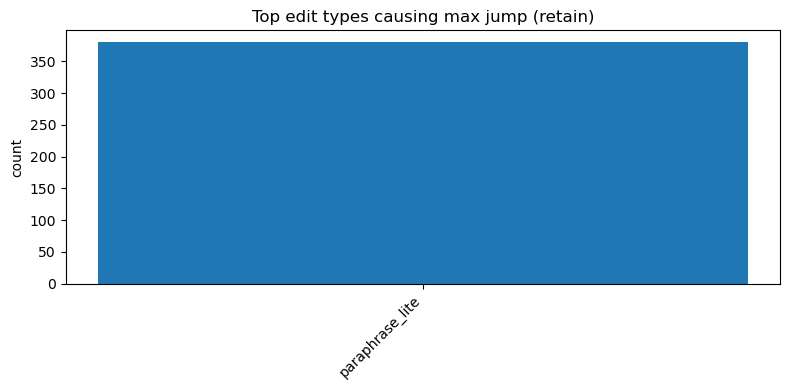

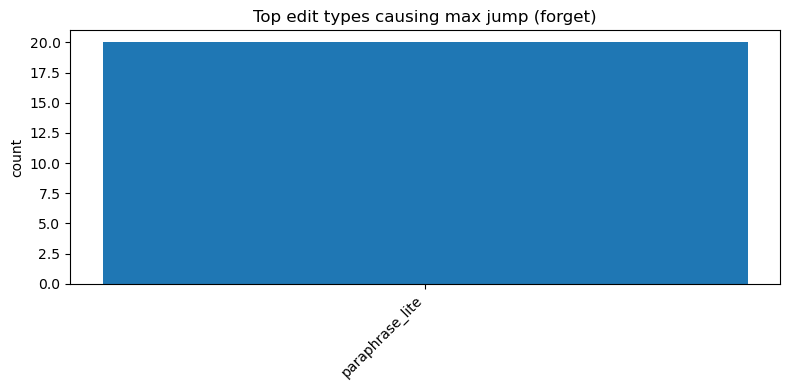

In [23]:
def plot_type_counts(label):
    sub = type_counts[type_counts["forget or retain"] == label].sort_values("count", ascending=False).head(15)
    plt.figure(figsize=(8,4))
    plt.bar(sub["type of edit"], sub["count"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top edit types causing max jump ({label})")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

plot_type_counts("retain")
plot_type_counts("forget")